In [19]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

/var/folders/h7/x_l9h5z577zf2sn8f721bpxc0000gn/T/ipykernel_26111/1486489113.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


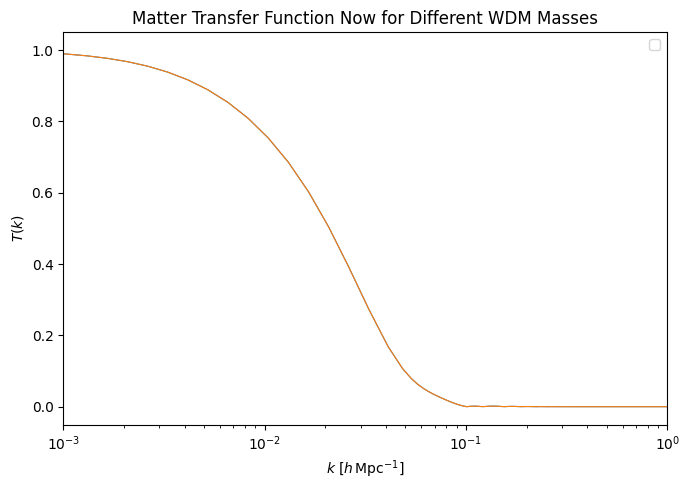

In [22]:
omega_dm = 0.1201075

m = 1
temp = 0.16 

# with data file
params1 = {
    "output": "mTk",

    "omega_cdm": 0.0,


    "omega_ncdm": omega_dm,
    "N_ncdm": 1,
    "m_ncdm": m,
    "T_ncdm": temp,
    "deg_ncdm": 2,

    "use_ncdm_psd_files": 1,
    "ncdm_psd_filenames": "SL_FDpsd.dat",
}

# with analytic distribution
params2 = {
    "output": "mTk",

    "omega_cdm": 0.0,


    "omega_ncdm": omega_dm,
    "N_ncdm": 1,
    "m_ncdm": m,
    "T_ncdm": temp,
    "deg_ncdm": 2,
}


# compute cosmologies
cosmo1 = Class()
cosmo1.set(params1)
cosmo1.compute()

cosmo2 = Class()
cosmo2.set(params2)
cosmo2.compute()


# get transfer function data
transfer_data1 = cosmo1.get_transfer(z=0)
ks1 = transfer_data1["k (h/Mpc)"]
d_m1 = transfer_data1['d_m']

transfer_data2 = cosmo2.get_transfer(z=0)
ks2 = transfer_data2["k (h/Mpc)"]
d_m2 = transfer_data2['d_m']


# normalizing transfer function properly
transfer1 = np.abs(d_m1) / ks1**2
transfer1 /= transfer1[0]

transfer2 = np.abs(d_m2) / ks2**2
transfer2 /= transfer2[0]

# Plot
plt.figure(figsize=(7, 5))
plt.xscale("log")
plt.xlim(1e-3, 1)
plt.plot(ks1, transfer1, lw=0.8)
plt.plot(ks2, transfer2, lw=0.8)
plt.xlabel(r"$k \ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$T(k)$")
plt.title("Matter Transfer Function Now for Different WDM Masses")
plt.legend()
plt.tight_layout()
plt.show()

There are some fluctuations at high frequency modes. I did find that the ks1 and ks2 don't exactly match, which might be the reaosn for that. Should explore    